In [56]:
try:
  #%tensorflow_version only exists in colab
  %tensorflow_version 2.x
except Exception:
    pass

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


## Getting out data ready(turning into tensors)
with all machine learning models, our data has to be in numerical format. So thats what we'll be doing first.
(numerical representations).
Let's start by accessing our data and checking out the lebels.

In [57]:
# Google Colab:
from google.colab import files
files.upload() # Upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("divyansh22/sheep-breed-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sheep-breed-classification' dataset.
Path to dataset files: /kaggle/input/sheep-breed-classification


In [59]:
import os

# List the contents of the downloaded dataset directory to find the correct CSV file
print(f"Contents of {path}:")
print(os.listdir(path))

Contents of /kaggle/input/sheep-breed-classification:
['SheepFaceImages']


In [60]:
import os
import pandas as pd

# The dataset root is at 'path' (e.g., '/kaggle/input/sheep-breed-classification')
# The images are in a subdirectory called 'SheepFaceImages'
data_dir = os.path.join(path, "SheepFaceImages") # Corrected path

# Build a DataFrame from the folder structure
records = []
for breed in os.listdir(data_dir):
    breed_path = os.path.join(data_dir, breed)
    if os.path.isdir(breed_path):
        for img_file in os.listdir(breed_path):
            records.append({"filename": os.path.join(breed_path, img_file), "label": breed})

labels_df = pd.DataFrame(records)
labels_df.head()
labels_df.describe()

,filename,label
count,1680,1680
unique,1680,4
top,/kaggle/input/sheep-breed-classification/Sheep...,Marino
freq,1,420


<Axes: xlabel='label'>

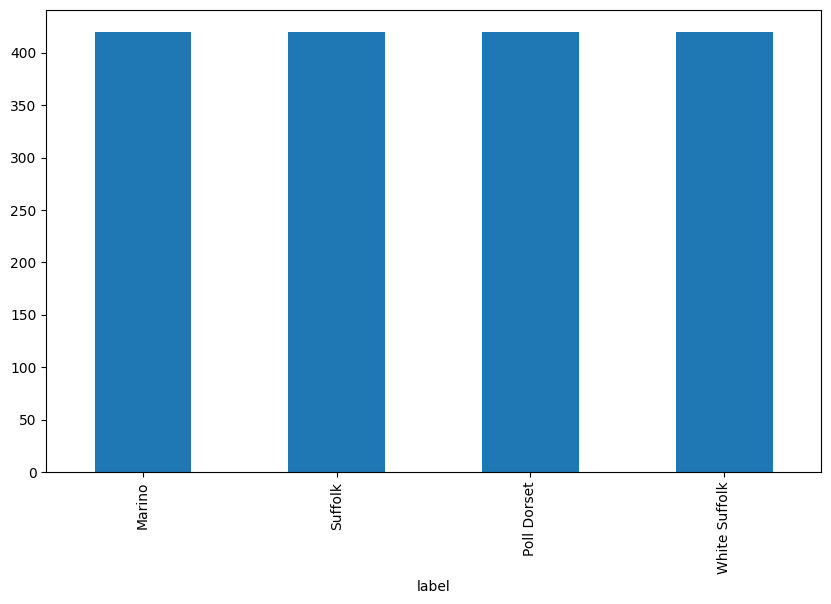

In [61]:
labels_df["label"].value_counts().plot.bar(figsize=(10, 6)) # Corrected column name to 'label' and added a default figsizeg for total number of data of breed

In [62]:
import os
import pandas as pd

# Correct data_dir by joining it with the full 'path' variable
data_dir = os.path.join(path, "SheepFaceImages")  # Corrected path
records = []
for breed in os.listdir(data_dir):
    breed_path = os.path.join(data_dir, breed)
    if os.path.isdir(breed_path):
        for img_file in os.listdir(breed_path):
            records.append({"filename": os.path.join(breed_path, img_file), "label": breed})
labels_df = pd.DataFrame(records)
# Check for missing values
print(labels_df.isnull().sum())
print("---")
print(f"Total missing values: {labels_df.isnull().sum().sum()}")

filename    0
label       0
dtype: int64
---
Total missing values: 0


In [63]:
import os
import pandas as pd

# Correct data_dir by using the 'path' variable from the dataset download
data_dir = os.path.join(path, "SheepFaceImages") # Corrected path

records = []
for breed in os.listdir(data_dir):
    breed_path = os.path.join(data_dir, breed)
    if os.path.isdir(breed_path):
        for img_file in os.listdir(breed_path):
            img_path = os.path.join(breed_path, img_file)
            records.append({"filename": img_file, "filepath": img_path, "label": breed})

labels_csv = pd.DataFrame(records)

# Save as CSV
labels_csv.to_csv("labels.csv", index=False)

# Preview
print(f"Total images: {len(labels_csv)}")
print(f"Breeds: {labels_csv['label'].unique()}")
print()
labels_csv.head(10)

Total images: 1680
Breeds: ['Marino' 'Suffolk' 'Poll Dorset' 'White Suffolk']



,filename,filepath,label
0,002412MB5.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
1,006146MK4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
2,24.jpgMA7.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
3,017005MZ4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
4,06.jpgMA8.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
5,004494MI4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
6,003738MD9.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
7,000203MD4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
8,008122MM4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
9,001204MA5.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino


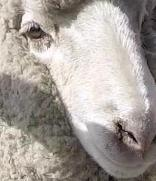

In [64]:
#visualising some images
from IPython.display import Image
Image("/kaggle/input/sheep-breed-classification/SheepFaceImages/Poll Dorset/000006 P.jpg")

**Getting Image with labels**

In [65]:
labels_csv.head()

,filename,filepath,label
0,002412MB5.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
1,006146MK4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
2,24.jpgMA7.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
3,017005MZ4.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino
4,06.jpgMA8.jpg,/kaggle/input/sheep-breed-classification/Sheep...,Marino


In [66]:
#Create pathnames from image ID's
filenames = [fname for fname in labels_csv["filename"]]

In [67]:
import numpy as np
labels = labels_csv["label"].to_numpy()
labels

array(['Marino', 'Marino', 'Marino', ..., 'White Suffolk',
       'White Suffolk', 'White Suffolk'], dtype=object)

In [68]:
len(labels)

1680

In [69]:
#checking if number of labels matches the number of filenames
if len(labels) == len(filenames):
  print("Number of labels matches number of filenames!")
else:
  print("Number of labels does not match number of filenames")

Number of labels matches number of filenames!


In [70]:
#Find the unique label values
unique_breeds = np.unique(labels)
unique_breeds
print(unique_breeds)
len(unique_breeds)

['Marino' 'Poll Dorset' 'Suffolk' 'White Suffolk']


4

**Turning a single label into an array of booleans **

In [71]:
print(labels[0])
labels[0]==unique_breeds

Marino


array([ True, False, False, False])

In [72]:
# Turn every label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]
dtype = bool

In [73]:
#setup X & Y variables
X = labels_csv["filepath"].to_numpy() # Use the full file paths
Y = np.array(boolean_labels).astype(np.float32)

In [74]:
len(filenames)

1680

**We** testing all 1680

In [75]:
NUM_IMAGES = 1680 #@param {type:"slider", min:1680, max:10000, step:10}

In [76]:
# split our data into train data and test data
from sklearn.model_selection import train_test_split

#split them into training and testing of total size NUM_IMAGES
X_train, X_test, Y_train, Y_test = train_test_split(X[:NUM_IMAGES],
                                                    Y[:NUM_IMAGES],
                                                    test_size=0.2,
                                                    random_state=42)
len(X_train), len(Y_train), len(X_test), len(Y_test)

(1344, 1344, 336, 336)

In [77]:
X_train[:5], Y_train[:2]

(array(['/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/004695MI4.jpg',
        '/kaggle/input/sheep-breed-classification/SheepFaceImages/Suffolk/crop007943BM1.jpg',
        '/kaggle/input/sheep-breed-classification/SheepFaceImages/Suffolk/71.jpgBH8.jpg',
        '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/017020MZ4.jpg',
        '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/014770MW4.jpg'],
       dtype=object),
 array([[1., 0., 0., 0.],
        [0., 0., 1., 0.]], dtype=float32))

##Preprocessing Images(Turning into tensors)
To preprocess our images into Tensors we're going to write a fuction which does a few things:
1. Take an image filepath as imput
2. Use TensorFlow To read the file and save it to a variable, image
3. Turn our image (a jpg) into Tensors
4. Resize the image to be a shape of (244, 224)
5. Return the Modified image

In [78]:
#create a fuction for preprocessing images
import tensorflow as tf
def process_image(image_path, img_size=224):
    """
    taking an image file path turn the image into a tensor
    """
    #Read in an image file
    image = tf.io.read_file(image_path)
    #Turn the Jpeg image into numerical tensor with 3 colour channels (Red, Green, Blue)
    image = tf.image.decode_jpeg(image, channels=3)
    #Convert the colour channels values from 0-255 to 0-1 values
    image = tf.image.convert_image_dtype(image, tf.float32)
    #Resize the image to our desired value (224, 224)
    image = tf.image.resize(image, size=[img_size, img_size])

    return image



```
# This is formatted as code
```

**Turning our data into batches**

Requirement: tuple

`(imaage, label)`

In [79]:
#create a simple fuction to return a tuple(image, label)
def get_image_label(image_path, label):
  """
  Takes an image file path name and the assosiated label,
  processes the image and return a tuple of (image, label).
  """
  image = process_image(image_path)
  return image, label

In [80]:
#checking how our output looklike
(process_image(X[42]), tf.constant(Y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.8941177 , 0.7960785 , 0.70980394],
         [0.88771015, 0.78967094, 0.7033964 ],
         [0.87006307, 0.77486   , 0.6876401 ],
         ...,
         [0.24814443, 0.19716404, 0.16186991],
         [0.25633767, 0.20535728, 0.17006315],
         [0.2627451 , 0.21176472, 0.1764706 ]],
 
        [[0.87457114, 0.77653193, 0.6902574 ],
         [0.86968446, 0.77164525, 0.6853707 ],
         [0.85263574, 0.75743264, 0.6702127 ],
         ...,
         [0.2683641 , 0.21738373, 0.18208961],
         [0.27334112, 0.22236075, 0.18706663],
         [0.27670693, 0.22572656, 0.19043244]],
 
        [[0.8789041 , 0.7808649 , 0.69459033],
         [0.8701891 , 0.77214986, 0.6858753 ],
         [0.84720904, 0.75200593, 0.6657694 ],
         ...,
         [0.26479498, 0.2138146 , 0.17852047],
         [0.26705098, 0.2160706 , 0.18077648],
         [0.268076  , 0.2170956 , 0.18180148]],
 
        ...,
 
        [[0.7279944 , 0.6848571 

In [81]:
#Define the batch size, 32 is a good start
BATCH_SIZE = 32

#Create a function to turn into batches
def create_data_batches(X, batch_size=BATCH_SIZE, Y=None, valid_data=False, test_data=False):
  """
  Creates batches of data out of image (X) and label (y) pairs.
  shuffles the data if it's training data but doesn't shuffle if it's validation data.
  also accepts test data as input (no labels).
  """
  #If the data is a test dataset, we probably don't have labels
  if test_data:
    print("creating test data batches... ")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X))) #only filepaths(no labels))
    data_batch = data.map(process_image).batch(batch_size) # Changed to process_image

    return data_batch

  #if the data is a valid dataset, we don't need to shuffle it
  elif valid_data:
    print("creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), #filepaths
                                               tf.constant(Y, dtype=tf.float32))) #labels

    data_batch = data.map(get_image_label).batch(batch_size)
    return data_batch

  else:
    print("Creating training data batches...")
    #Turn filepaths and labels into Tensors
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                             tf.constant(Y, dtype=tf.float32)))
    #shuffling pathnames and labels before mapping image processor function is faster than shuffle
    data = data.shuffle(buffer_size=len(X))

    #Create (image, label) tuples (this also turns the image path into a preprocessed image)
    data = data.map(get_image_label)

    #turn the training data into batches
    data_batch = data.batch(batch_size)
    return data_batch

In [82]:
#creating a data batch with the full data set
full_data = create_data_batches(X, Y=Y)

Creating training data batches...


In [83]:
full_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [84]:
#Creating trainng and testing data batches
train_data = create_data_batches(X_train, Y=Y_train)
test_data = create_data_batches(X_test, Y=Y_test, valid_data=True)

Creating training data batches...
creating validation data batches...


In [85]:
#check out the diffrence attribytes of our data batches
train_data.element_spec, test_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)))

**Building Deep leanring model by using tensorflow**

In [86]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [87]:
IMG_SIZE = 224

#Setup  input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3]

#Setup output shape of our model
OUTPUT_SHAPE =  len(unique_breeds)

In [88]:
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE):
  print("Building native Keras 3 MobileNetV2 feature extractor...")
  # Start with an explicit input layer
  inputs = tf.keras.Input(shape=input_shape[1:])
  # Getting the pre-trained MobileNetV2 model natively from Keras
  # include_top=False means we only get the feature extractor, not the 1000-class ImageNet output
  full_model = tf.keras.applications.MobileNetV2(
      input_shape=(224, 224, 3),
      include_top=False,
      weights='imagenet'
  )

  # Freeze the pre-trained weights so we don't destroy them finding sheep breeds!
  full_model.trainable = False

  # Pass inputs through the full model
  x = full_model(inputs, training=False)

  # TF Hub "feature_vector" models automatically apply global average pooling.
  x = tf.keras.layers.GlobalAveragePooling2D()(x)

  # Adding final classification layer
  outputs = tf.keras.layers.Dense(units=output_shape, activation="softmax", name='output_layer')(x)

  # Build the final functional model
  model = tf.keras.Model(inputs, outputs)

  # Compile the model
  model.compile(
      loss=tf.keras.losses.CategoricalCrossentropy(),
      optimizer=tf.keras.optimizers.Adam(),
      metrics=["accuracy"]
  )
  return model
model = create_model()
model.summary()

Building native Keras 3 MobileNetV2 feature extractor...
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 output_layer (Dense)        (None, 4)                 5124      
                                                                 
Total params: 2263108 (8.63 MB)
Trainable params: 5124 (20.02 KB)
Non-trainable params: 2257984 (8.61 MB)
____________________________

In [89]:
#create full model
full_model = create_model()

Building native Keras 3 MobileNetV2 feature extractor...


**TensorBoard Callback**

In [90]:
#load tensorbaord notebook extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [91]:
import datetime
#create a fuction to build a Tensorboard callback
def create_tensorboard_callback():
  #create a log directory for storing TensorBoard Logs
  logdir = os.path.join("/content/logs",
                        #making it so the logs get tracked whenever we run this an project
                          datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

  return tf.keras.callbacks.TensorBoard(logdir)


**Early stoping model to avoid overfitting**

In [92]:
#creating callback fuction for early stopping model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                   patience=3,
restore_best_weights=True)

**Training a model(full dataset)**

In [93]:
NUM_EPOCHS = 100

In [94]:
#checking to make sure our gpu is working
print("GPU", "available(It's available!!!!)" if tf.config.list_physical_devices("GPU") else "not available:(")

GPU available(It's available!!!!)


In [95]:
# Create model callbacks
full_model_tensorboard = create_tensorboard_callback()
full_model_early_stopping = early_stopping

In [96]:
#Fit the model to the data
full_model.fit(x=train_data,
               epochs=NUM_EPOCHS,
               validation_data=test_data,
               callbacks=[full_model_tensorboard,
                          full_model_early_stopping])

Epoch 1/100
42/42 [==============================] - 6s 71ms/step - loss: 1.0588 - accuracy: 0.5499 - val_loss: 0.7422 - val_accuracy: 0.7143
Epoch 2/100
42/42 [==============================] - 2s 49ms/step - loss: 0.6599 - accuracy: 0.7485 - val_loss: 0.5952 - val_accuracy: 0.7708
Epoch 3/100
42/42 [==============================] - 2s 53ms/step - loss: 0.5380 - accuracy: 0.8147 - val_loss: 0.5181 - val_accuracy: 0.8095
Epoch 4/100
42/42 [==============================] - 2s 50ms/step - loss: 0.4647 - accuracy: 0.8430 - val_loss: 0.4842 - val_accuracy: 0.8274
Epoch 5/100
42/42 [==============================] - 2s 57ms/step - loss: 0.4100 - accuracy: 0.8728 - val_loss: 0.4346 - val_accuracy: 0.8393
Epoch 6/100
42/42 [==============================] - 2s 49ms/step - loss: 0.3719 - accuracy: 0.8876 - val_loss: 0.4119 - val_accuracy: 0.8482
Epoch 7/100
42/42 [==============================] - 3s 75ms/step - loss: 0.3305 - accuracy: 0.9055 - val_loss: 0.3932 - val_accuracy: 0.8571
Epoch 

In [97]:
import os
import pathlib

# This will print the exact folder location where your notebook is running
current_folder = os.getcwd()
print("Your notebook is running in:", current_folder)

# This will print the exact full path to your saved model
model_path = pathlib.Path("full-image-set-mobilenetv2-Adam.keras").absolute()
print("Your model is saved exactly here:", model_path)


Your notebook is running in: /content
Your model is saved exactly here: /content/full-image-set-mobilenetv2-Adam.keras


In [98]:
def save_model(model, suffix):
    model.save(suffix)
    print(f"Model saved to {suffix}")

In [99]:
import os
save_path = "full-image-set-mobilenetv2-Adam.keras"
full_model.save(save_path)
print(f"Model saved at: {os.path.abspath(save_path)}")

Model saved at: /content/full-image-set-mobilenetv2-Adam.keras


In [100]:
import os
import tensorflow as tf

# Force use of legacy Keras for loading to match the saved model format
try:
    import tf_keras
    load_method = tf_keras.models.load_model
except ImportError:
    load_method = tf.keras.models.load_model

# Ensure the model is saved first
save_path = 'full-image-set-mobilenetv2-Adam.keras'
full_model.save(save_path)
print(f'Model saved at: {os.path.abspath(save_path)}')

# Now load the model using the appropriate loader
loaded_full_model = load_method(save_path)
print('Model loaded successfully using legacy loader!')

Model saved at: /content/full-image-set-mobilenetv2-Adam.keras
Model loaded successfully using legacy loader!


**Making Prediction on the test dataset**

In [101]:
import os

# The dataset root is stored in the 'path' variable from the kagglehub download
# Based on previous cells, the images are inside 'SheepFaceImages'
data_dir = os.path.join(path, "SheepFaceImages")

# Since there is no specific 'test' folder in this dataset structure,
# we can collect filenames from the breed subdirectories.
test_filenames = []
for breed in os.listdir(data_dir):
    breed_path = os.path.join(data_dir, breed)
    if os.path.isdir(breed_path):
        for fname in os.listdir(breed_path):
            test_filenames.append(os.path.join(breed_path, fname))

print(f"Found {len(test_filenames)} images.")
test_filenames[:10]

Found 1680 images.


['/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/002412MB5.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/006146MK4.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/24.jpgMA7.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/017005MZ4.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/06.jpgMA8.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/004494MI4.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/003738MD9.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/000203MD4.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/008122MM4.jpg',
 '/kaggle/input/sheep-breed-classification/SheepFaceImages/Marino/001204MA5.jpg']

In [102]:
len(test_filenames)

1680

In [103]:
# Create unlabeled Kaggle test data batch (images only, no labels)
kaggle_test_data = create_data_batches(test_filenames, test_data=True)

creating test data batches... 


In [104]:
kaggle_test_data

<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [105]:
#Make prediction on test data batch using the loaded full model
test_predictions = loaded_full_model.predict(kaggle_test_data,
                                             verbose=1)

53/53 [==============================] - 3s 44ms/step


In [106]:
# save predictions (NumPy array) to csv file (for access later)
np.savetxt("sheep_breed_predictions.csv", test_predictions, delimiter=",")
print("Predictions saved successfully as sheep_breed_predictions.csv")

Predictions saved successfully as sheep_breed_predictions.csv


In [107]:
#load predictions (NumPy array) from csv file
test_predictions = np.loadtxt("/content/sheep_breed_predictions.csv", delimiter=",")
print("Predictions loaded successfully")

Predictions loaded successfully


Getting predition of test data

In [108]:
#create a fuction to unbatch a batch dataset
def unbatchify(data, has_labels=True):
    """
    Take a batched dataset of Tensors and returns separate arrays.
    """
    images = []
    labels = []
    # loop through unbatched data
    for item in data.unbatch().as_numpy_iterator():
        if has_labels:
            image, label = item
            images.append(image)
            labels.append(unique_breeds[np.argmax(label)])
        else:
            image = item
            images.append(image)

    return (images, labels) if has_labels else images

# unbatchify the testing data (which has no labels)
test_images = unbatchify(test_data, has_labels=False)
test_images[0]

(array([[[0.5019608 , 0.454902  , 0.40000004],
         [0.6066177 , 0.55955887, 0.5046569 ],
         [0.7120799 , 0.665021  , 0.61011904],
         ...,
         [0.42352945, 0.69411767, 0.8588236 ],
         [0.41995794, 0.69411767, 0.8588236 ],
         [0.4156863 , 0.69411767, 0.8588236 ]],
 
        [[0.5969013 , 0.5498425 , 0.49494052],
         [0.65593284, 0.608874  , 0.55397207],
         [0.7064203 , 0.6593615 , 0.6044595 ],
         ...,
         [0.42699495, 0.6962369 , 0.86161596],
         [0.4227503 , 0.69691   , 0.86161596],
         [0.41847867, 0.69691   , 0.86161596]],
 
        [[0.7025999 , 0.655541  , 0.60063905],
         [0.72762936, 0.68057054, 0.6256686 ],
         [0.74485016, 0.69779134, 0.6428894 ],
         ...,
         [0.42839634, 0.6970939 , 0.86274517],
         [0.42573702, 0.69803923, 0.86274517],
         [0.423687  , 0.69803923, 0.86274517]],
 
        ...,
 
        [[0.41160724, 0.3645484 , 0.30964643],
         [0.38930944, 0.3422506 , 0.28734

Now we've got ways to get get:
*   Prediction labels
*   Validation labels (truth labels)
*   Validation images

Making some function to visaulize.
We'll create a function which:
* Takes an array of prediction probabilities, an array of truth labels and an array of images and integers.
* Convert the prediction probabilities to a predicted label.
* Plot the the predicted label, its predicted probability, the truth label and target image on single plot.

In [109]:
import matplotlib.pyplot as plt
def plot_pred(prediction_probabilities, labels, images, n=1):
    """
    view the prediction, ground truth and image for sample n

    """
    pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

    #Get the pred label
    pred_label = unique_breeds[pred_prob.argmax()]

    #plot image & remove ticks
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

 #change the colour of the title depending
    if pred_label == true_label:
         color = "green"
    else:
        color = "red"

   #change plot title to be predicted, probability of prediction and truth label
    plt.title("{}{:2.0f}% {}".format(pred_label,
                                 np.max(pred_prob)*100,
                                 true_label),
                                 color=color)

53/53 [==============================] - 3s 60ms/step


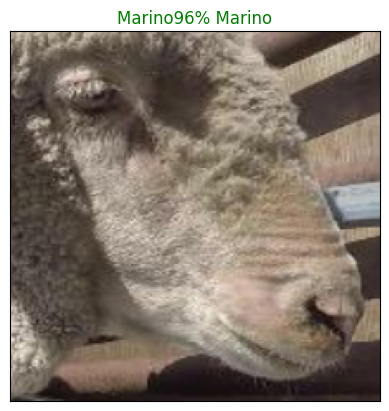

In [111]:
# The model predictions were already made and stored in test_predictions in a previous cell.
test_predictions = full_model.predict(kaggle_test_data, verbose=1)

# Create test_labels from Y_test (which holds the true labels) and unique_breeds
# Y_test contains one-hot encoded labels, so argmax gives the index of the true label
test_labels = [unique_breeds[np.argmax(label)] for label in Y_test]

# The 'test_images' variable from the kernel state is a list of (image_array, label_array) tuples.
# We need to extract only the image arrays for plotting.
images_for_plotting = [item[0] for item in test_images] # Extract the image array from each tuple

# Now plot works!
plot_pred(prediction_probabilities=test_predictions,
          labels=test_labels,
          images=images_for_plotting, # Use the corrected list of images
          n=45)

#Make fuction to view top 10 prediction


In [112]:
def plot_pred_conf(prediction_probabilities, labels, n=1):
    """
    plot the top 10 prediction confidences along with the truth label for sample n.
    """
    pred_prob, true_label = prediction_probabilities[n], labels[n]

    #Get the predicted label
    pred_label = get_pred_label(pred_prob)

    #find the top 10 prediction confidence indexes
    top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]

    #Find the top 10 prediction confidence indexes
    top_10_pred_values = pred_prob[top_10_pred_indexes]

    #Find the top 10 prediction labels
    top_10_pred_labels = unique_breeds[top_10_pred_indexes]

    #setup plot
    top_plot = plt.bar(np.arange(len(top_10_pred_labels)),
                      top_10_pred_values,
                      color="grey")
    plt.xticks(np.arange(len(top_10_pred_labels)),
               labels=top_10_pred_labels,
               rotation="vertical")

    #change color of true label
    if np.isin(true_label, top_10_pred_labels):
        top_plot[np.argmax(top_10_pred_labels == true_label)].set_color("green")

In [113]:
#function to get predicted label from prediction probabilities
def get_pred_label(prediction_probabilities):
    return unique_breeds[prediction_probabilities.argmax()]

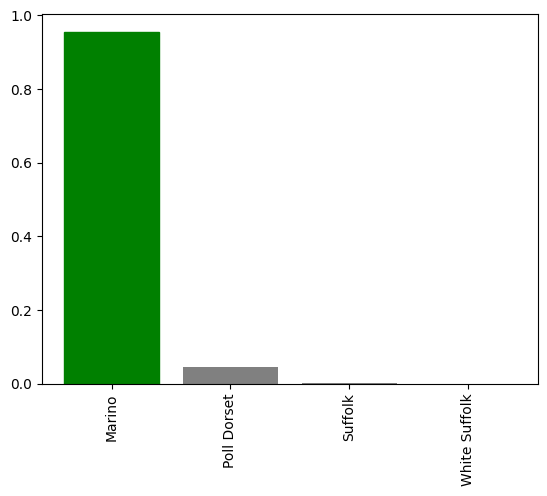

In [114]:
plot_pred_conf(prediction_probabilities=test_predictions,
               labels=test_labels,
               n=45)

**Visualizing our predictions and evaluating model**

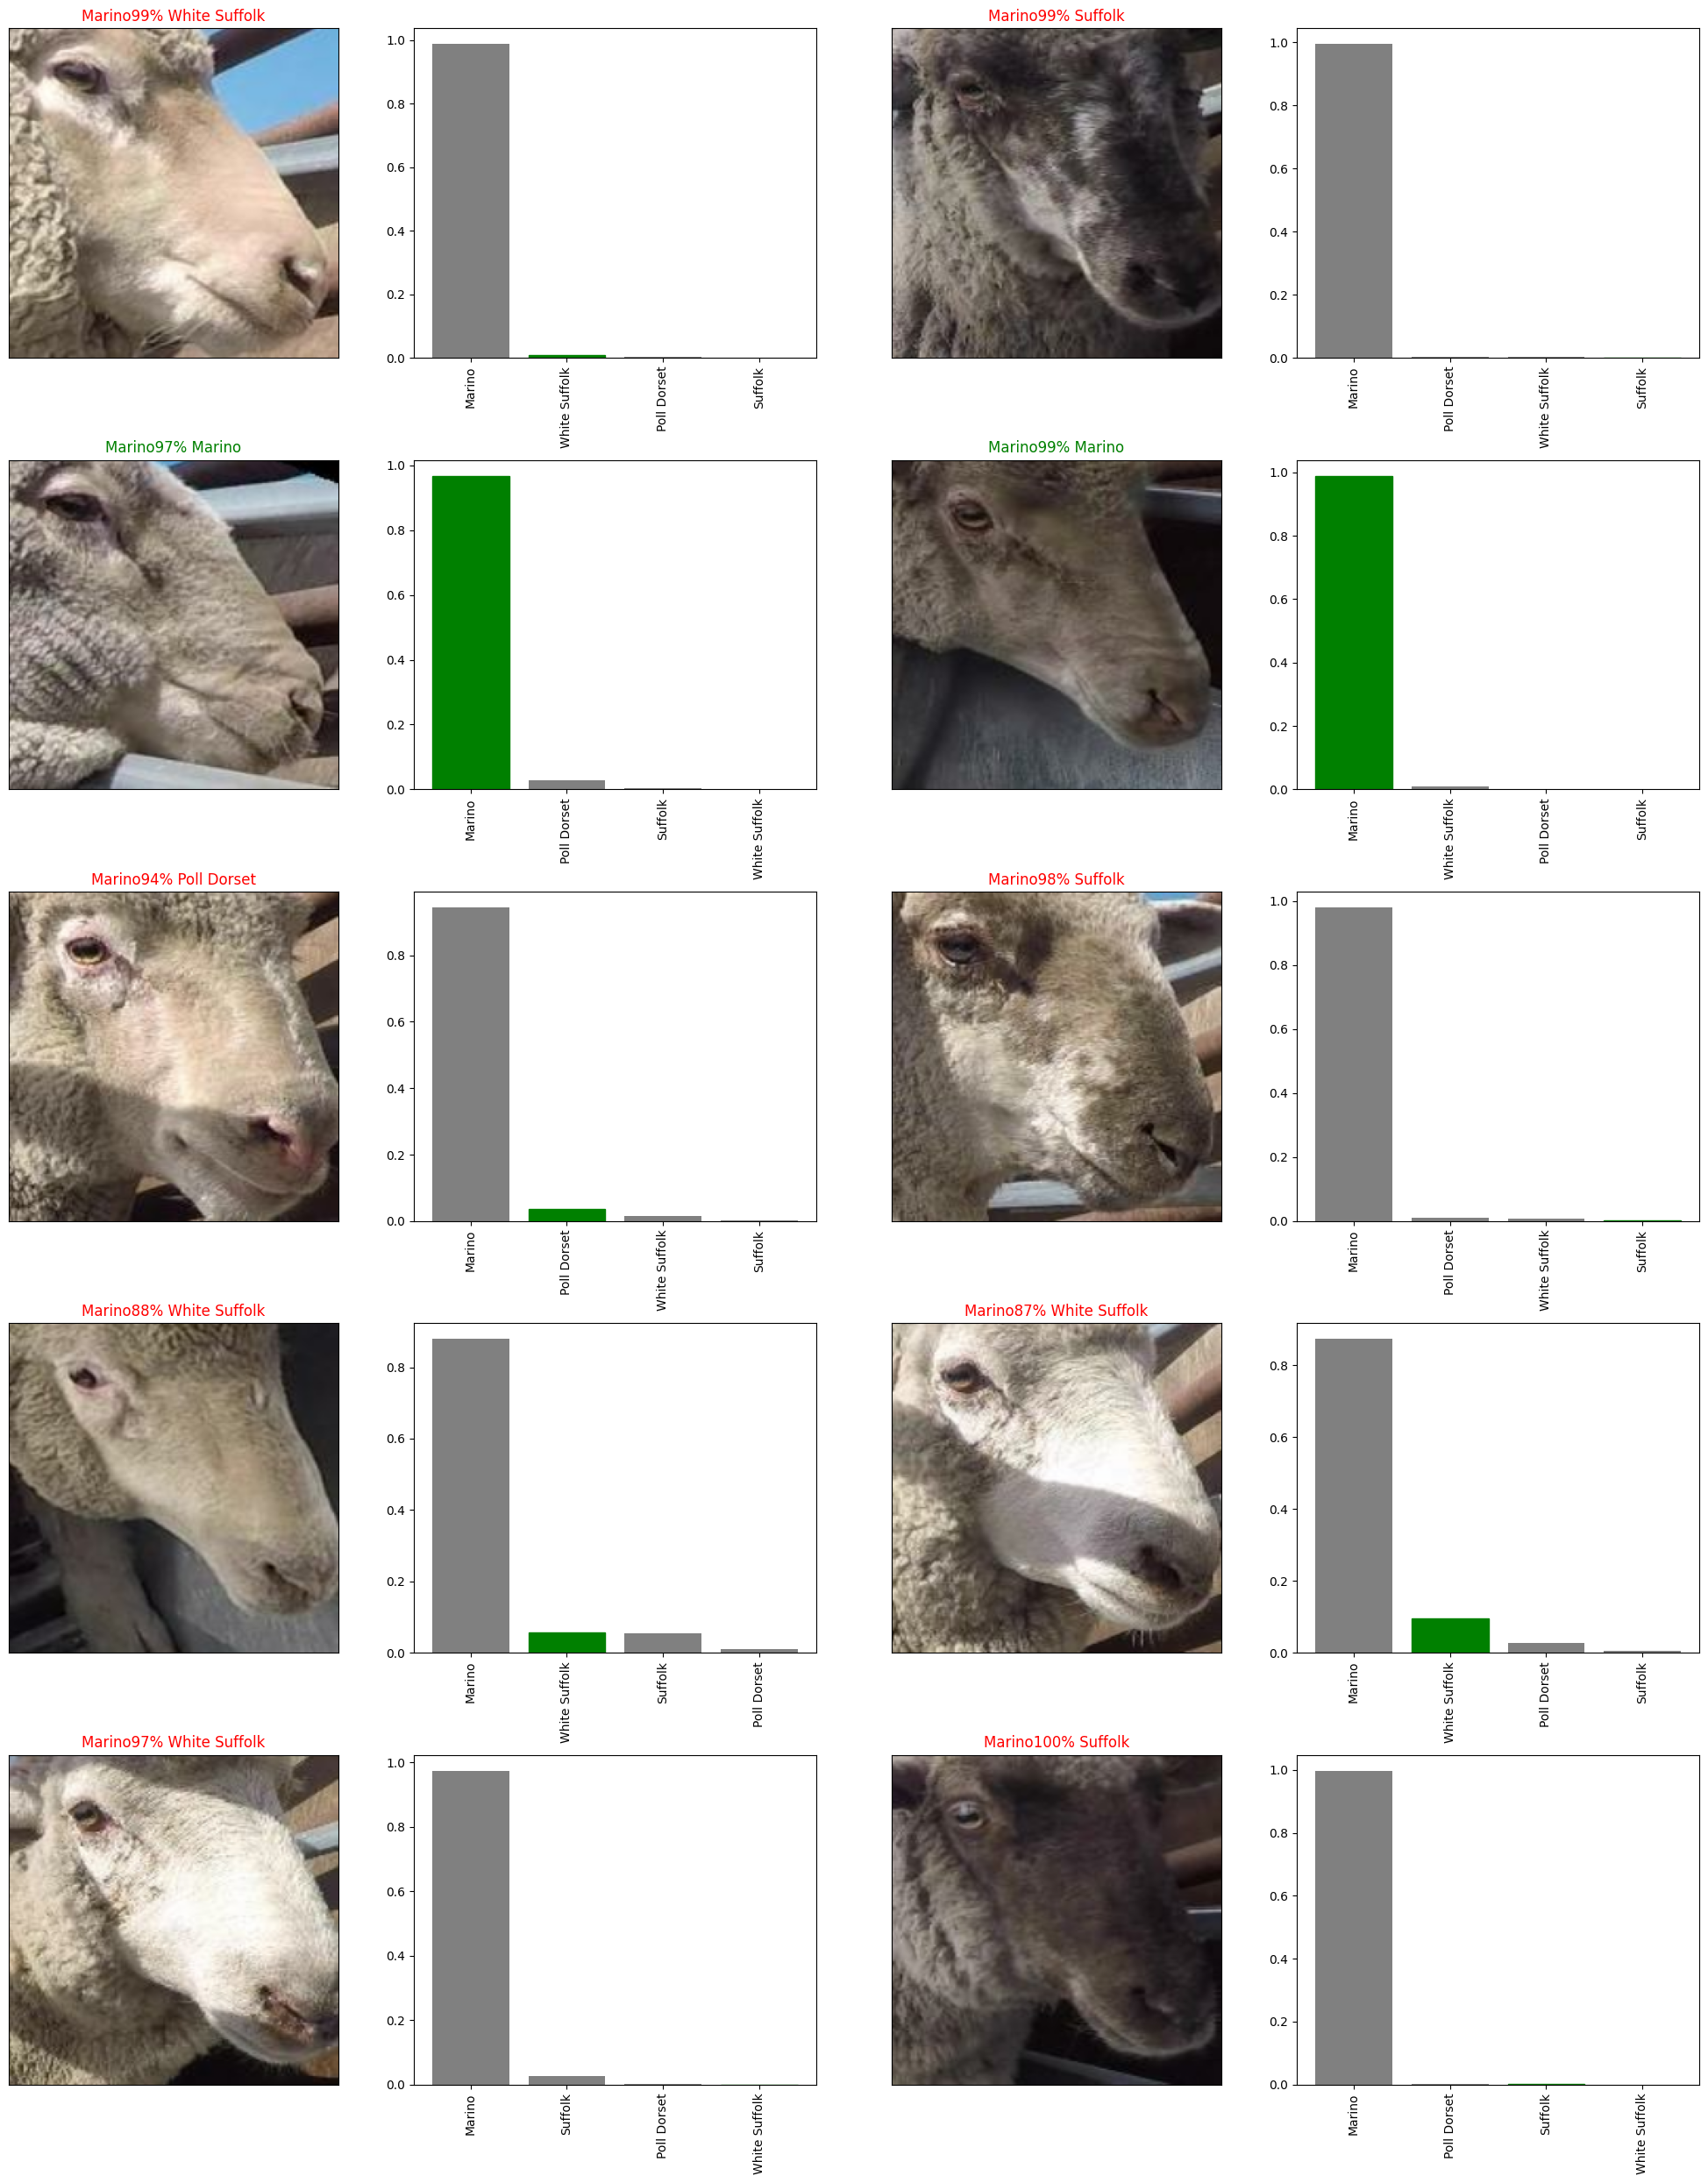

In [115]:
#checking out a few predition and thier diffrenct values
i_multiplier = 0
num_rows = 5
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(10*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  # Use the extracted image arrays to avoid passing tuples to imshow
  plot_pred(prediction_probabilities=test_predictions,
            labels=test_labels,
            images=images_for_plotting,
            n=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=test_predictions,
                 labels=test_labels,
                 n=i+i_multiplier)

plt.tight_layout(h_pad=1.0)
plt.show()

**Saving and reloading a trained model**

In [116]:
#create a fuction to save a model
def save_model(model, suffix=None):
    """
    saves a given model in a models directory and appends a suffix (string).
    """
    #create a model directory pathname with current time
    modeldir = os.path.join("/content/drive/MyDrive/Sheep Breed classification",
                            datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    model_path = modeldir + "-" + suffix + ".h5" #save format of model
    print(f"Saving model to: {model_path}...")
    model.save(model_path)
    return model_path

In [117]:
import tensorflow_hub as hub

#create a fuction to load a trained model
def load_model(model_path):
    print(f"Loading saved model from: {model_path}")
    model = tf.keras.models.load_model(model_path,
                                       custom_objects={"KerasLayer":hub.KerasLayer})

    return model

In [118]:
# Load and overwrite the model variable using the locally saved model path
import os

# We use the path established in previous successful saving steps
model_path = "full-image-set-mobilenetv2-Adam.keras"

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print(f"Model loaded successfully from {model_path}")
else:
    print(f"Error: {model_path} not found. Please run the cell that saves the model first.")

Model loaded successfully from full-image-set-mobilenetv2-Adam.keras


In [119]:
#Save out model
save_model(model, suffix="full-image-set-mobilenetv2-Adam")

Saving model to: /content/drive/MyDrive/Sheep Breed classification/20260313-102336-full-image-set-mobilenetv2-Adam.h5...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


'/content/drive/MyDrive/Sheep Breed classification/20260313-102336-full-image-set-mobilenetv2-Adam.h5'

In [120]:
# Use the model file we just saved locally in cell DQEjTjogtbeR
import os

local_model_path = 'full-image-set-mobilenetv2-Adam.keras'

if os.path.exists(local_model_path):
    # Using the load_method logic established in previous cells
    try:
        import tf_keras
        load_full_model = tf_keras.models.load_model(local_model_path)
    except ImportError:
        load_full_model = tf.keras.models.load_model(local_model_path)

    print(f'Model loaded successfully from: {os.path.abspath(local_model_path)}')
else:
    print(f'Error: {local_model_path} not found. Please run the save_model cell first.')

Model loaded successfully from: /content/full-image-set-mobilenetv2-Adam.keras


In [121]:
#Evalute the pre-saved model
model.evaluate(test_data)

11/11 [==============================] - 1s 39ms/step - loss: 0.2449 - accuracy: 0.9196


[0.24492871761322021, 0.9196428656578064]

In [122]:
#Evaluate the loaded model
load_full_model.evaluate(test_data)

11/11 [==============================] - 2s 39ms/step - loss: 0.2449 - accuracy: 0.9196


[0.24492871761322021, 0.9196428656578064]